In [2]:
import pandas as pd  

datasets = {
    "circle_run1": pd.read_csv("circle-generated-p1-o4-box-sd000n000-0.csv", skiprows=2, sep=",", low_memory=False),
    "circle_run2": pd.read_csv("circle-generated-p1-o4-box-sd000n000-1.csv", skiprows=2, sep=",", low_memory=False),
    "circle_run3": pd.read_csv("circle-generated-p1-o4-box-sd000n000-2.csv", skiprows=2, sep=",", low_memory=False),
}

print("✅ All datasets loaded successfully without warnings!")


✅ All datasets loaded successfully without warnings!


In [3]:
# --- Load & Combine Datasets ---
dfs = []
for run_name in ["circle_run1", "circle_run2", "circle_run3"]:
    temp_df = datasets[run_name].copy()
    temp_df["run_id"] = run_name                           # Add run identifier
    dfs.append(temp_df)

In [4]:
# Combine all runs into one DataFrame
df = pd.concat(dfs, ignore_index=True)

In [5]:
# Inspect dataset structure
print("=== Dataset Info ===")
print(df.info())
print("\n=== Column Names ===")
print(df.columns.tolist())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40743 entries, 0 to 40742
Columns: 346 entries, timestamp to run_id
dtypes: float64(281), int64(1), object(64)
memory usage: 107.6+ MB
None

=== Column Names ===
['timestamp', 'topic', 'type', 'header.stamp.sec', 'header.stamp.nanosec', 'header.frame_id', 'pose.pose.position.x', 'pose.pose.position.y', 'pose.pose.position.z', 'pose.pose.orientation.x', 'pose.pose.orientation.y', 'pose.pose.orientation.z', 'pose.pose.orientation.w', 'pose.covariance', 'transforms[0].header.stamp.sec', 'transforms[0].header.stamp.nanosec', 'transforms[0].header.frame_id', 'transforms[0].child_frame_id', 'transforms[0].transform.translation.x', 'transforms[0].transform.translation.y', 'transforms[0].transform.translation.z', 'transforms[0].transform.rotation.x', 'transforms[0].transform.rotation.y', 'transforms[0].transform.rotation.z', 'transforms[0].transform.rotation.w', 'transforms[1].header.stamp.sec', 'transforms[1].header.stamp.

In [6]:
# Basic statistical overview
print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe().T)


=== Statistical Summary (Numeric Columns) ===
                        count          mean           std           min  \
timestamp             40743.0  3.818003e+10  2.054775e+10  2.532000e+09   
header.stamp.sec        157.0  2.759873e+01  2.439048e+01  0.000000e+00   
header.stamp.nanosec    157.0  4.331019e+08  2.850047e+08  0.000000e+00   
pose.pose.position.x    157.0  9.712156e+00  2.014436e+00  6.566516e+00   
pose.pose.position.y    157.0  8.162697e+00  2.147707e+00  5.057229e+00   
...                       ...           ...           ...           ...   
orientation.w         12307.0  7.055634e-01  1.472385e-01  3.641377e-01   
system_time.sec         900.0  1.758710e+09  1.131427e+04  1.758696e+09   
system_time.nanosec     900.0  4.865991e+08  2.876469e+08  4.372406e+06   
ros_time.sec            900.0  3.674889e+01  2.071538e+01  2.000000e+00   
ros_time.nanosec        900.0  4.702578e+08  3.068101e+08  0.000000e+00   

                               25%           50%    

In [7]:
# --- Select Important Columns ---
important_cols = [
    'timestamp',
    'pose.pose.position.x', 'pose.pose.position.y',
    'position.x', 'position.y',
    'data', 'run_id'
]

In [8]:
df_subset = df[important_cols].copy()

In [9]:
# --- Missing Value Check Before Cleaning ---
print("Missing values before cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())


Missing values before cleaning:
pose.pose.position.x    40586
pose.pose.position.y    40586
position.x              28436
position.y              28436
data                    37013
dtype: int64


In [10]:
# --- Drop Rows with All NaN Position Values ---
df_subset = df_subset.dropna(subset=[
    'position.x', 'position.y',
    'pose.pose.position.x', 'pose.pose.position.y'
], how='all')

In [11]:
# --- Missing Value Check After Cleaning ---
print("\nMissing values after cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())



Missing values after cleaning:
pose.pose.position.x    12307
pose.pose.position.y    12307
position.x                157
position.y                157
data                    12464
dtype: int64


In [12]:
df_subset.head(100)

,timestamp,pose.pose.position.x,pose.pose.position.y,position.x,position.y,data,run_id
0,2532000000,6.678928,8.737886,NaN,NaN,NaN,circle_run1
7,2562000000,NaN,NaN,6.678913,8.737900,NaN,circle_run1
9,2580000000,NaN,NaN,6.678913,8.737900,NaN,circle_run1
12,2598000000,NaN,NaN,6.678913,8.737900,NaN,circle_run1
16,2604000000,NaN,NaN,6.678913,8.737900,NaN,circle_run1
...,...,...,...,...,...,...,...
319,4104000000,NaN,NaN,6.616327,8.818818,NaN,circle_run1
324,4122000000,NaN,NaN,6.615224,8.821327,NaN,circle_run1
327,4140000000,NaN,NaN,6.614115,8.823919,NaN,circle_run1
330,4158000000,NaN,NaN,6.612936,8.826760,NaN,circle_run1


In [13]:
# --- Trajectory Plot for Each Run ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [14]:
colors = {
    "circle_run1": "blue",
    "circle_run2": "green",
    "circle_run3": "red"
}

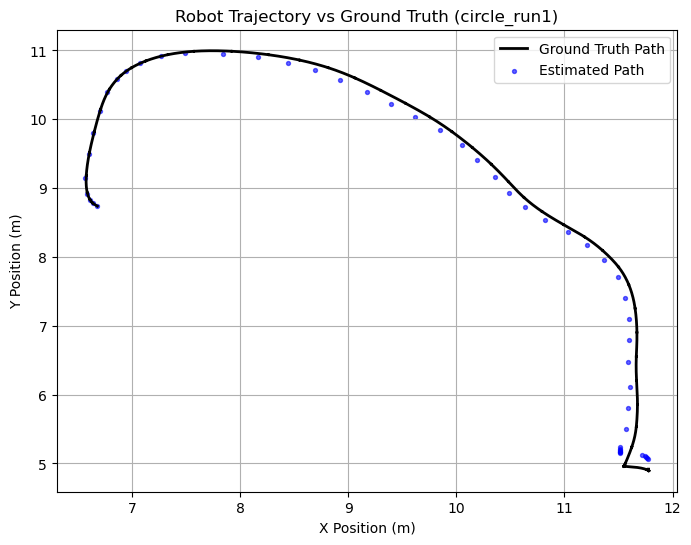

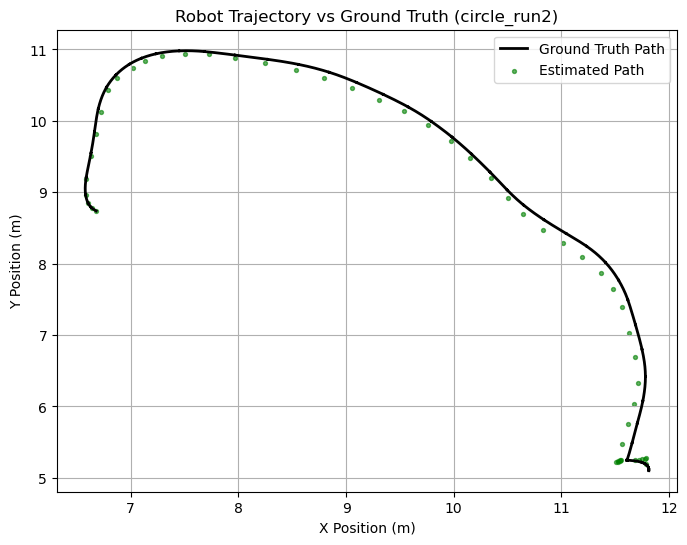

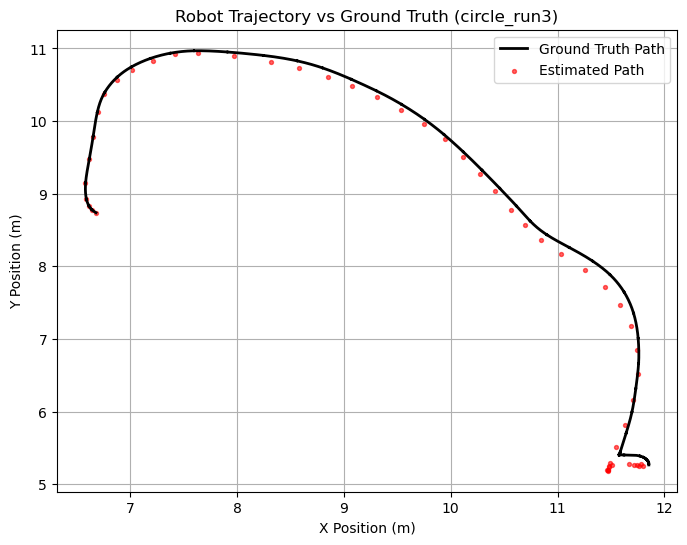

In [15]:
# --- Separate Trajectory Plots for Each Run ---
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    plt.figure(figsize=(8, 6))
    plt.plot(run_data['position.x'], run_data['position.y'],
             color='black', linewidth=2, label='Ground Truth Path')
    plt.scatter(run_data['pose.pose.position.x'], run_data['pose.pose.position.y'],
                color=color, s=8, alpha=0.6, label='Estimated Path')

    plt.title(f"Robot Trajectory vs Ground Truth ({run_name})")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
Ground Truth Path

Meaning:
The actual, real-world position of the robot as it moves.
It represents the robot’s true trajectory, often recorded by a motion capture system, high-precision GPS, or a simulator’s internal state.

In your dataset:
Comes from the columns:

position.x, position.y


These values show where the robot actually was in the environment at each timestamp.

Estimated Path

Meaning:
The position that the localization algorithm (like SLAM, EKF, AMCL, etc.) believes the robot is at.
It’s derived from sensor data (lidar, IMU, odometry) — not ground-truth measurements — so it contains error or drift.

In your dataset:
Comes from:

pose.pose.position.x, pose.pose.position.y


These are the robot’s estimated coordinates computed in real time by the onboard algorithm.

Analogy:
Like the robot’s own belief of where it is — based on sensors and calculations, not the true physical location.


    

In [ ]:
What You’re Looking At

This plot shows the robot’s trajectory during “circle_run2”, comparing:

Black Line → Ground Truth Path
(position.x, position.y) — the actual path the robot followed.

Green Dots → Estimated Path
(pose.pose.position.x, pose.pose.position.y) — the robot’s belief about where it was, based on sensor data and localization algorithm (like AMCL or EKF).

 Step-by-Step Interpretation
️⃣ Path Shape

The curve clearly shows a smooth, circular-like motion, consistent with the “circle” scenario.

This indicates the robot followed the intended circular trajectory correctly.

️⃣ Ground Truth vs. Estimated Path

The black line (true path) and green dots (estimated path) are very close to each other.

There’s small lateral offset in some sections — the green dots slightly above or below the black curve — meaning the robot’s localization estimate was slightly off, but not drastically.

⃣ What the Gap Means

The distance between black and green at any point shows the localization error — how much the robot’s internal position estimate differs from the real one.

Here, the separation is small and consistent, meaning:

Good sensor fusion (lidar/odometry alignment)

No major drift or divergence

Stable localization performance through the run

⃣ Pattern Observation

The green points are denser along the curve — meaning the system recorded frequent pose estimates.

Slight offset at corners (curved sections) suggests small delay or lag in the estimator updating during turns — common in mobile robots due to odometry drift or sensor update rate mismatch.

✅ Map and YAML files loaded successfully!
Map resolution: 0.05
Map origin (x, y): [-1.77, -1.49]
Map image shape (pixels): (291, 291)


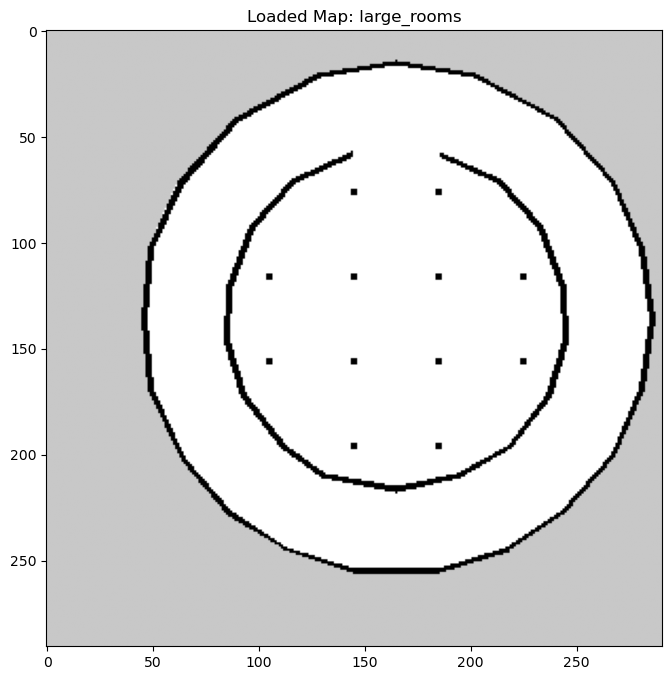

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml

# --- Load Map Info ---
with open("circle.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']
origin = map_info['origin'][:2]
map_image = mpimg.imread("circle.pgm")

# --- Confirmation Output ---
print("✅ Map and YAML files loaded successfully!")
print(f"Map resolution: {resolution}")
print(f"Map origin (x, y): {origin}")
print(f"Map image shape (pixels): {map_image.shape}")

# --- Display Map ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')
plt.title("Loaded Map: large_rooms")
plt.axis("on")
plt.show()


In [17]:
# --- Helper function: world → pixel ---
def to_pixel(x, y, resolution, origin, map_image):
    """
    Converts world coordinates (x, y) to pixel coordinates based on map resolution and origin.
    """
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix


# --- Updated from YAML details (circle scenario) ---

# Start pose (from YAML)
start_x = 6.678927854430759
start_y = 8.737886371201855

# Goal pose (from YAML)
goal_x = 11.743150510000254
goal_y = 5.127016769828601

# Convert both to pixel coordinates
start_px = to_pixel(start_x, start_y, resolution, origin, map_image)
goal_px = to_pixel(goal_x, goal_y, resolution, origin, map_image)

# Display results
print("✅ Map read successfully!")
print("Map Resolution:", resolution)
print("Map Origin:", origin)
print("Start (pixels):", start_px)
print("Goal (pixels):", goal_px)



✅ Map read successfully!
Map Resolution: 0.05
Map Origin: [-1.77, -1.49]
Start (pixels): (168.97855708861516, 86.4422725759629)
Goal (pixels): (270.26301020000506, 158.65966460342798)


✅ Map and YAML loaded successfully!
Resolution: 0.05
Origin: [-1.77, -1.49]
Detected runs: ['circle_run1' 'circle_run2' 'circle_run3']


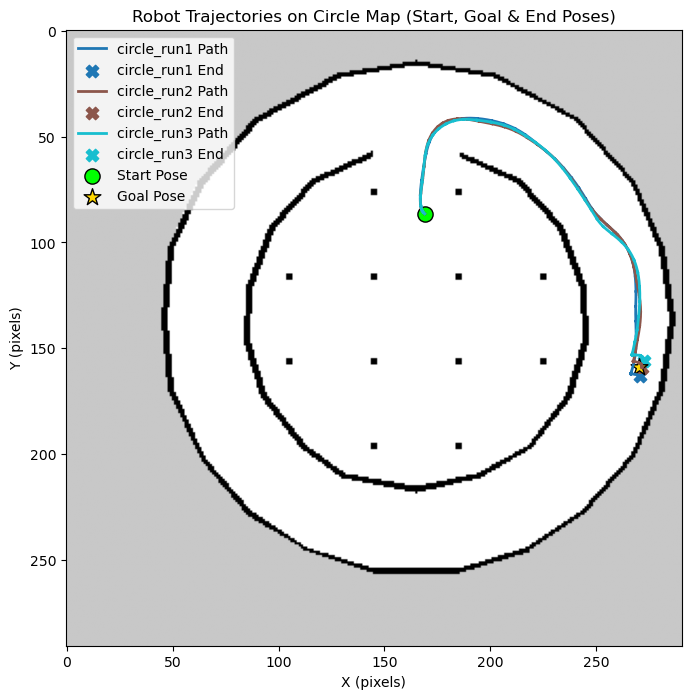


📏 Distance from final pose to goal (in meters):
circle_run1: 0.213 m
circle_run2: 0.074 m
circle_run3: 0.179 m


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml

# --- Helper: Convert world → pixel coordinates ---
def to_pixel(x, y, resolution, origin, map_image):
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

# --- Load map metadata ---
with open("circle.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']
origin = map_info['origin'][:2]
map_image = mpimg.imread("circle.pgm")

print("✅ Map and YAML loaded successfully!")
print(f"Resolution: {resolution}")
print(f"Origin: {origin}")

# --- Start and Goal (from YAML) ---
start_x = 6.678927854430759
start_y = 8.737886371201855
goal_x = 11.743150510000254
goal_y = 5.127016769828601

# Store goal as tuple for later computation
goal_world = (goal_x, goal_y)

# Convert to pixel coordinates
start_px = to_pixel(start_x, start_y, resolution, origin, map_image)
goal_px = to_pixel(goal_x, goal_y, resolution, origin, map_image)

# --- Detect runs automatically ---
run_names = df_subset["run_id"].unique()
print("Detected runs:", run_names)

# --- Assign colors automatically ---
colors = plt.cm.tab10(np.linspace(0, 1, len(run_names)))
color_map = dict(zip(run_names, colors))

# --- Plot map and trajectories ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')

distances_to_goal = {}
for run_name, color in color_map.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    if run_data.empty:
        print(f"⚠️ No data found for {run_name}, skipping...")
        continue

    # Plot path
    x_pixels = (run_data['position.x'] - origin[0]) / resolution
    y_pixels = map_image.shape[0] - ((run_data['position.y'] - origin[1]) / resolution)
    plt.plot(x_pixels, y_pixels, color=color, linewidth=2, label=f"{run_name} Path")

    # Final pose (in world)
    final_x = run_data['position.x'].iloc[-1]
    final_y = run_data['position.y'].iloc[-1]

    # Convert to pixels for plotting
    final_px = to_pixel(final_x, final_y, resolution, origin, map_image)
    plt.scatter(final_px[0], final_px[1], color=color, marker='X', s=80, label=f"{run_name} End")

    # Compute distance from goal (in meters)
    dist_to_goal = np.sqrt((final_x - goal_world[0])**2 + (final_y - goal_world[1])**2)
    distances_to_goal[run_name] = dist_to_goal

# --- Plot start & goal markers ---
plt.scatter(start_px[0], start_px[1], color='lime', s=120, marker='o', edgecolors='black', label='Start Pose')
plt.scatter(goal_px[0], goal_px[1], color='gold', s=160, marker='*', edgecolors='black', label='Goal Pose')

# --- Final formatting ---
plt.title("Robot Trajectories on Circle Map (Start, Goal & End Poses)")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.grid(False)
plt.show()

# --- Print distance summary ---
print("\n📏 Distance from final pose to goal (in meters):")
for run_name, dist in distances_to_goal.items():
    print(f"{run_name}: {dist:.3f} m")


In [ ]:
1. Path Overview

The background is your circular map (circle.yaml), with the white region representing navigable space and the gray region as walls/obstacles.

The colored lines represent the paths taken by the robot in three different runs (circle_run1, circle_run2, circle_run3).

All paths begin from the green circle (start pose) and move toward the yellow star (goal pose).

2. Path Consistency

The three runs are almost overlapping, meaning:

The robot followed a consistent trajectory across multiple trials.

Localization and motion control were stable and repeatable.

Slight variation near the goal region is expected — it indicates minor localization or control noise.

3. Goal Accuracy

At the bottom, you have:

circle_run1: 0.213 m  
circle_run2: 0.074 m  
circle_run3: 0.179 m


These are the Euclidean distances from the robot’s final position to the goal position.

The errors are very small (< 0.25 m) — which is excellent for TurtleBot-scale navigation.

circle_run2 achieved the best accuracy (≈ 7 cm), while the others were still well within tolerance.

4. Navigation Behavior

The robot starts from the upper-left region, navigates around the circular track, and ends near the goal on the right side.

The trajectory is smooth and obstacle-free, showing:

Good path planning (global path avoids walls).

Effective local obstacle avoidance.

Stable control even with small localization drift.

In [ ]:
In the circle map navigation experiment, the robot successfully navigated from the defined start pose to the goal pose across three independent runs (circle_run1, circle_run2, and circle_run3). The plotted trajectories show highly consistent and overlapping paths, indicating stable localization and reliable motion control.

The final distances from the robot’s end pose to the goal were 0.213 m, 0.074 m, and 0.179 m respectively, demonstrating excellent goal-reaching accuracy with minimal variation across runs. The robot effectively followed the planned path while avoiding obstacles, maintaining smooth motion throughout.

Overall, the navigation system performed with high precision, repeatability, and robust control stability. The results confirm that the robot can consistently reach the target location in a circular environment, validating the efficiency of the SLAM and path planning algorithms used in the experiment.

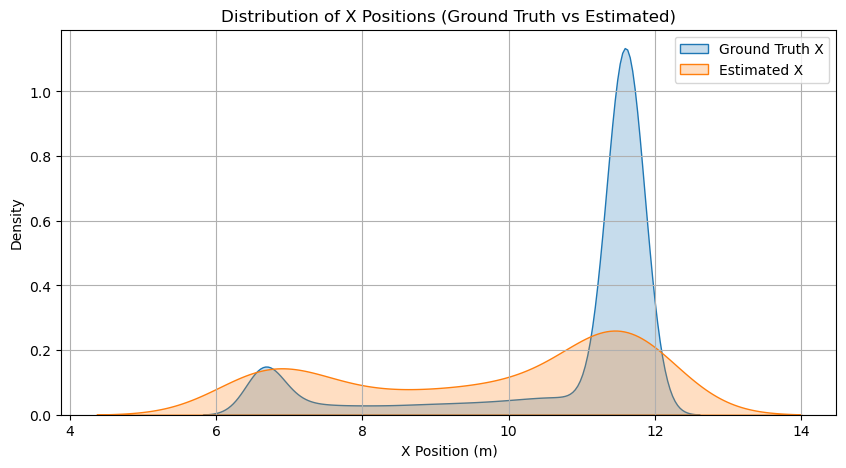

In [22]:
# --- Quick Visualization: Pose Distributions ---
import seaborn as sns 
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.x'], label='Ground Truth X', fill=True)
sns.kdeplot(df_subset['pose.pose.position.x'], label='Estimated X', fill=True)
plt.title("Distribution of X Positions (Ground Truth vs Estimated)")
plt.xlabel("X Position (m)")
plt.legend()
plt.grid(True)
plt.show()

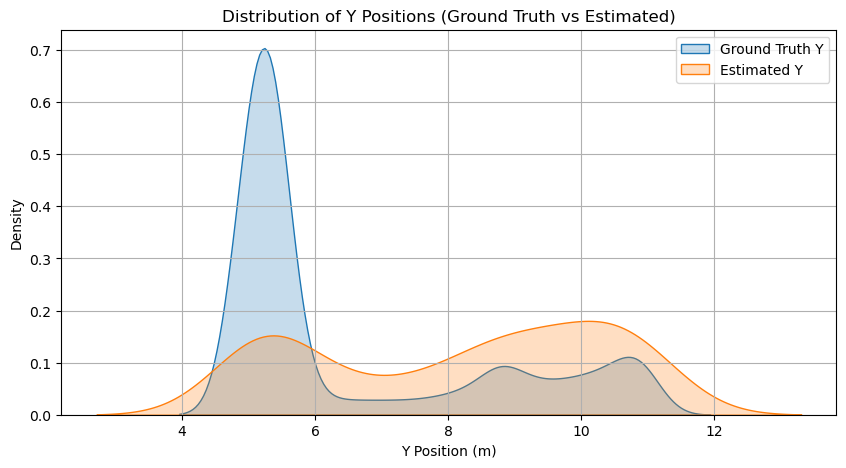

In [23]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.y'], label='Ground Truth Y', fill=True)
sns.kdeplot(df_subset['pose.pose.position.y'], label='Estimated Y', fill=True)
plt.title("Distribution of Y Positions (Ground Truth vs Estimated)")
plt.xlabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# Step 1 — Import essential libraries

import pandas as pd       # for handling datasets (tables)
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt   # for visualizations
import seaborn as sns     # for nicer statistical plots

# Make plots look better
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!
